In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from db_config import CONN_STR


engine = create_engine(CONN_STR)


query = """
SELECT 
    m.*, 
    o.category_id, 
    o.ceremony, 
    o.year_film, 
    o.year_ceremony, 
    o.winner
FROM 
    main.dim_movie m
LEFT JOIN 
    main.fact_oscar_awards o 
ON 
    m.movie_id = o.movie_id
"""

# Завантаження даних у датафрейм
df = pd.read_sql(query, engine)

# Перегляд перших 5 рядків для перевірки
print(df.head())

# Перегляд основної інформації про датафрейм
print(df.info())

   movie_id                                              title release_date  \
0      1055                                        Topsy-Turvy   2000-02-11   
1      1033                                   The Time Machine   2002-03-08   
2       918                                       The Way Back   2011-01-21   
3       815                                            Ed Wood   1994-10-07   
4       565  The Lord of the Rings: The Fellowship of the Ring   2001-12-19   

   year      genre rating  runtime_minutes      budget   production_company  \
0  1999  Biography      R            160.0         NaN        Goldwyn Films   
1  2002     Action  PG-13             96.0  80000000.0         Warner Bros.   
2  2010  Adventure  PG-13            133.0  30000000.0      Exclusive Films   
3  1994  Biography      R            127.0  18000000.0  Touchstone Pictures   
4  2001     Action  PG-13            178.0  93000000.0      New Line Cinema   

          country  category_id  ceremony  year_fil

In [11]:

# Створення бінарної колонки для наявності Оскара
df['has_oscar'] = np.where(df['category_id'].notnull(), 1, 0)

# Оброббка відсутніх значень
df['rating'] = df['rating'].fillna('Unknown')
df['runtime_minutes'] = df['runtime_minutes'].fillna(df['runtime_minutes'].median())
df['budget'] = df['budget'].fillna(df['budget'].median())
df['production_company'] = df['production_company'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Перевірка наявності відсутніх значень
print(df.isnull().sum())
print(df['has_oscar'].value_counts())

movie_id                 0
title                    0
release_date             0
year                     0
genre                    0
rating                   0
runtime_minutes          0
budget                   0
production_company       0
country                  0
category_id           6510
ceremony              6510
year_film             6510
year_ceremony         6510
winner                6510
has_oscar                0
dtype: int64
has_oscar
0    6510
1    3148
Name: count, dtype: int64


In [12]:
#  SQL запит для отримання даних про касові збори
query = """
SELECT movie_id, worldwide AS worldwide_gross
FROM main.fact_box_office
"""

df_box_office = pd.read_sql(query, engine)

# Злиття даних про касові збори з основним датафреймом
df = df.merge(df_box_office, on='movie_id', how='left')

# Перевірка результатів злиття
print(df[['movie_id', 'worldwide_gross']].head())
print(df['worldwide_gross'].isnull().sum())

   movie_id  worldwide_gross
0      1055              NaN
1      1033      123729176.0
2       918       24172201.0
3       815              NaN
4       565      868385360.0
6123


1. Попередній аналіз даних

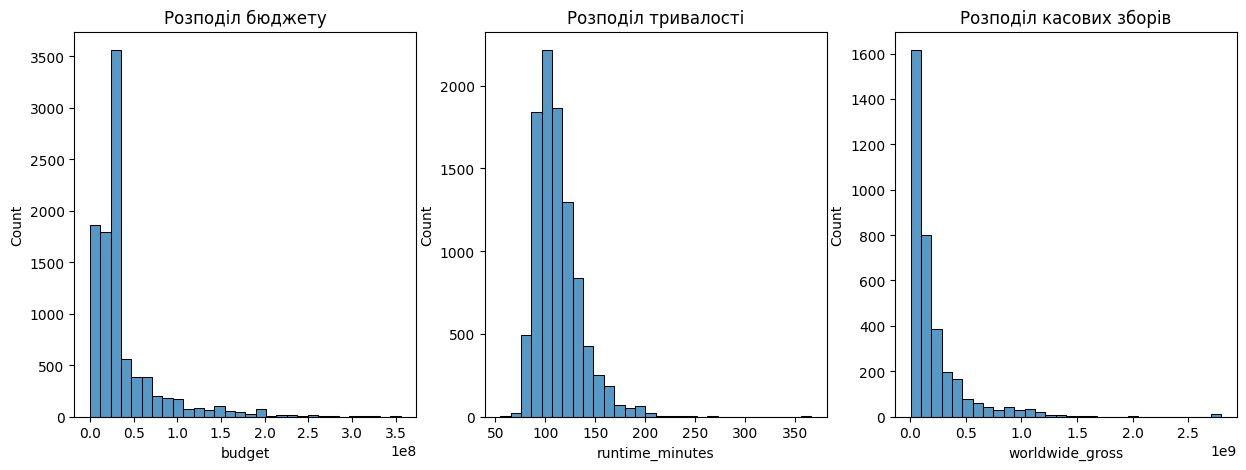

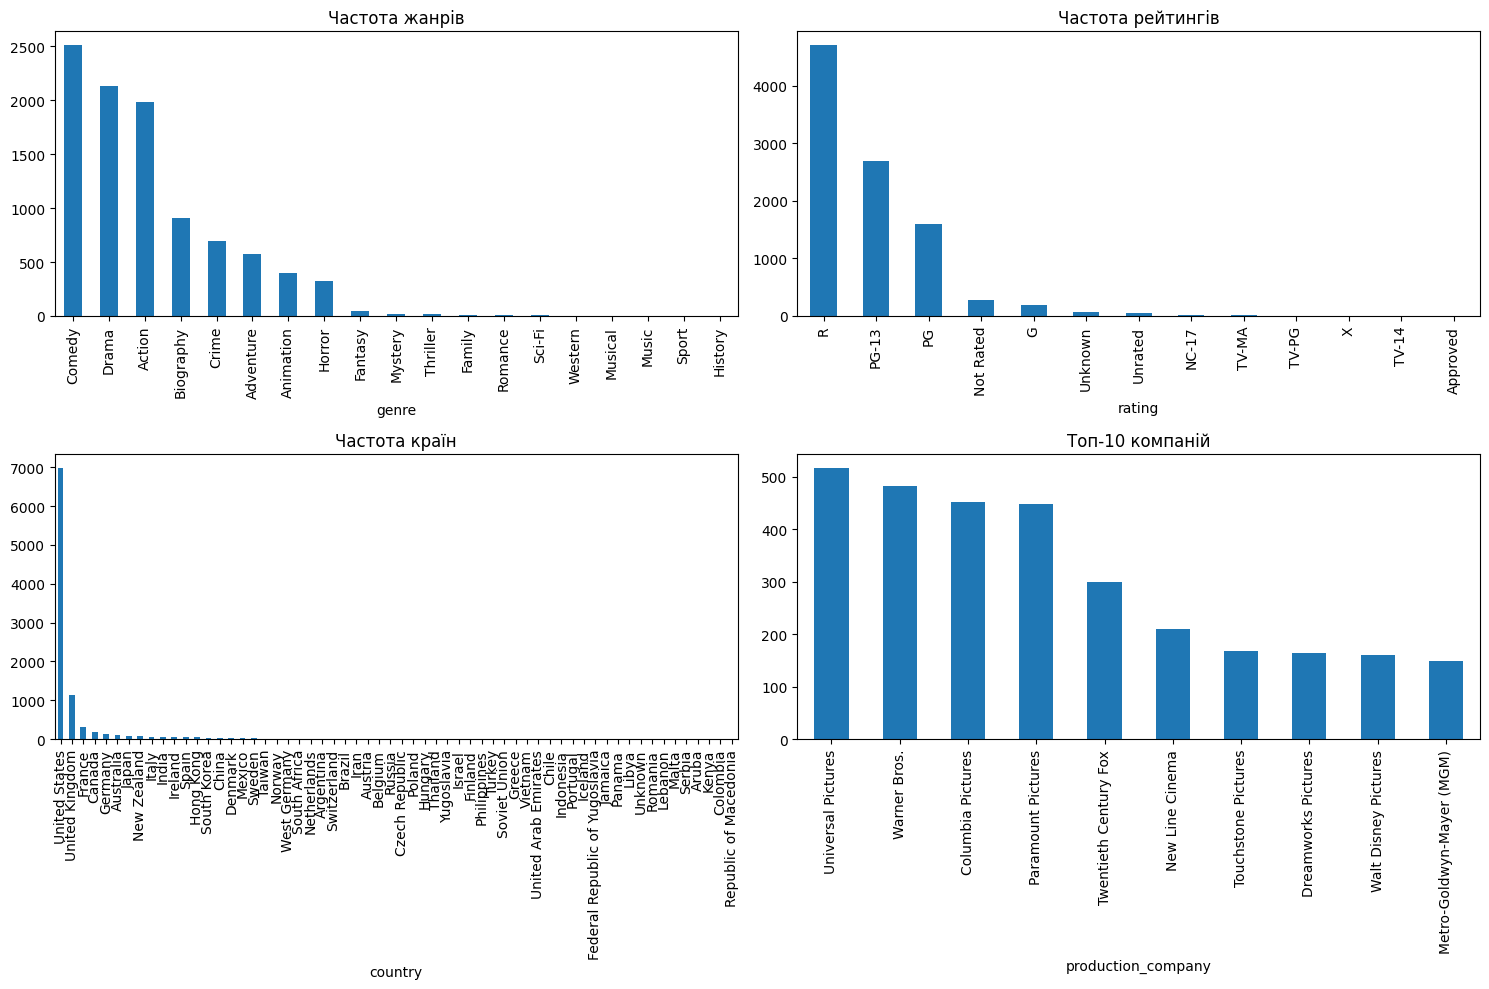

In [13]:
# 1.1. Аналіз розподілу даних

# Гістограми для числових ознак
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['budget'].dropna(), bins=30)
plt.title('Розподіл бюджету')

plt.subplot(1, 3, 2)
sns.histplot(df['runtime_minutes'].dropna(), bins=30)
plt.title('Розподіл тривалості')

plt.subplot(1, 3, 3)
sns.histplot(df['worldwide_gross'].dropna(), bins=30)
plt.title('Розподіл касових зборів')
plt.show()

# Стовпчасті діаграми для категоріальних ознак
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
df['genre'].value_counts().plot(kind='bar')
plt.title('Частота жанрів')

plt.subplot(2, 2, 2)
df['rating'].value_counts().plot(kind='bar')
plt.title('Частота рейтингів')

plt.subplot(2, 2, 3)
df['country'].value_counts().plot(kind='bar')
plt.title('Частота країн')

plt.subplot(2, 2, 4)
df['production_company'].value_counts().head(10).plot(kind='bar')
plt.title('Топ-10 компаній')
plt.tight_layout()
plt.show()

Ось детальний огляд вмісту двох зображень із гістограмами, які відображають розподіл різних змінних у наборі даних про фільми. Я проаналізую кожен набір гістограм окремо, щоб дати повне уявлення про розподіли та їх значення.

---

### **Зображення 0: Розподіл бюджету, тривалості та касових зборів**
Ця картинка містить три гістограми, які показують розподіл числових змінних: бюджету, тривалості фільмів та світових касових зборів.

1. **Розподіл бюджету (Budget Distribution)**  
   - **Опис**: Гістограма має сильний правосторонній скос. Більшість фільмів мають бюджет у межах від 0 до 50 мільйонів (0–0.5e8), із піком частоти близько 3500 для бюджетів, близьких до 0. Частота різко зменшується зі збільшенням бюджету, і лише кілька фільмів мають бюджет понад 150 мільйонів (1.5e8), із винятками до 350 мільйонів (3.5e8).  
   - **Висновок**: Більшість фільмів у наборі даних — це низькобюджетні проєкти, тоді як високобюджетні фільми є рідкістю.

2. **Розподіл тривалості (Runtime Distribution)**  
   - **Опис**: Гістограма має приблизно нормальний розподіл із легким правостороннім скосом. Більшість фільмів тривають від 75 до 150 хвилин, із піком частоти близько 2000 для тривалості приблизно 100 хвилин. Кількість фільмів із тривалістю менше 50 хвилин або більше 200 хвилин значно менша, хоча є винятки до 350 хвилин.  
   - **Висновок**: Тривалість більшості фільмів зосереджена в типовому діапазоні 1.5–2 години, що є стандартним для кіноіндустрії.

3. **Розподіл касових зборів (Worldwide Gross Distribution)**  
   - **Опис**: Гістограма також має сильний правосторонній скос. Більшість фільмів мають світові касові збори від 0 до 500 мільйонів (0–0.5e9), із піком частоти близько 1600 для зборів, близьких до 0. Кількість фільмів із доходами понад 1.5 мільярда (1.5e9) дуже мала, із винятками до 2.5 мільярда (2.5e9).  
   - **Висновок**: Більшість фільмів мають відносно низькі касові збори, а блокбастери з величезними доходами є рідкісними.

- **Загальні спостереження**: Усі три гістограми показують правосторонній скос, що вказує на те, що більшість фільмів мають нижчі бюджети, коротшу тривалість і менші касові збори, із невеликою кількістю винятків на вищому кінці. Тривалість є найбільш симетричною змінною, тоді як бюджет і касові збори мають сильнішу концентрацію біля нуля.

---

### **Зображення 1: Частота жанрів, рейтингів, країн і компаній**
Ця картинка містить чотири гістограми, які відображають частоту категоріальних змінних: жанрів, рейтингів, країн походження та топ-10 виробничих компаній.

1. **Частота жанрів (ЧАСТОТА ЖАНРІВ)**  
   - **Опис**: Найпоширеніші жанри — це **Комедія** (~2500), **Драма** (~2000) і **Екшн** (~1500). Менш популярні жанри включають **Історія** (~25), **Спорт** (~50) і **Мюзикл** (~50).  
   - **Висновок**: Комедія, Драма та Екшн домінують у наборі даних, що може відображати їхню комерційну популярність. Рідкісні жанри, як Історія, можуть бути нішевими або менш привабливими для масового виробництва.

2. **Частота рейтингів (ЧАСТОТА РЕЙТИНГІВ)**  
   - **Опис**: Найпоширеніший рейтинг — **R** (~4000), за ним ідуть **PG-13** (~3000) і **PG** (~1500). Найменш часті рейтинги — **X** (~25), **TV-14** (~50) і **TV-PG** (~50).  
   - **Висновок**: Переважання рейтингів R і PG-13 може вказувати на орієнтацію на дорослу аудиторію або підлітків, тоді як менш поширені рейтинги можуть бути пов’язані з телевізійними форматами чи застарілими стандартами.

3. **Частота країн (ЧАСТОТА КРАЇН)**  
   - **Опис**: **Сполучені Штати** значно переважають із ~6500 фільмами, за ними йдуть **Велика Британія** (~1000), **Франція** (~750) і **Канада** (~500). Багато країн, як-от **Колумбія** чи **Кенія**, мають лише ~25 фільмів.  
   - **Висновок**: Домінування США відображає вплив Голлівуду. Наявність інших країн із низькою частотою показує різноманітність, але їхній внесок незначний.

4. **Топ-10 компаній (ТОП-10 КОМПАНІЙ)**  
   - **Опис**: Лідирує **Universal Pictures** (~500), за нею йдуть **Warner Bros. Pictures** (~450) і **Columbia Pictures** (~400). Найменша частота серед топ-10 — у **Metro-Goldwyn-Mayer (MGM)** (~150).  
   - **Висновок**: Великі голлівудські студії домінують у виробництві, що може корелювати з їхніми ресурсами та можливостями для маркетингу й дистрибуції.

---

### **Загальний аналіз і подальші кроки**
- **Числові змінні (Зображення 0)**: Правосторонній скос бюджетів і касових зборів свідчить про те, що більшість фільмів є низькобюджетними й мають скромні доходи, тоді як тривалість має більш збалансований розподіл. Це може вплинути на прогнозування успіху: наприклад, високобюджетні фільми можуть мати більші шанси на високі збори, але їх мало.
- **Категоріальні змінні (Зображення 1)**: Домінування певних жанрів (Комедія, Драма), рейтингів (R, PG-13), країн (США) і компаній (Universal, Warner Bros.) підкреслює комерційні тенденції в кіноіндустрії. Ці змінні можуть бути ключовими для прогнозування успіху чи номінацій на нагороди.
- **Подальші кроки**:
  - Дослідити кореляцію між жанрами, рейтингами чи компаніями та касовими зборами чи номінаціями на Оскар (наприклад, чи частіше драми отримують нагороди?).
  - Згрупувати країни чи компанії з низькою частотою в категорію "Інше" для спрощення аналізу.
  - Створити графіки (наприклад, box plots), щоб порівняти середні касові збори за жанрами чи рейтингами.

Ці гістограми є чудовою основою для розуміння розподілів у наборі даних і можуть допомогти у виборі ознак для подальшого моделювання чи аналізу.

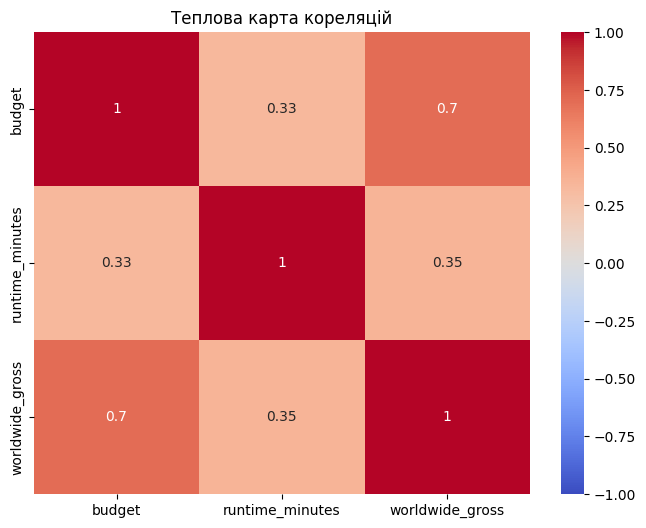

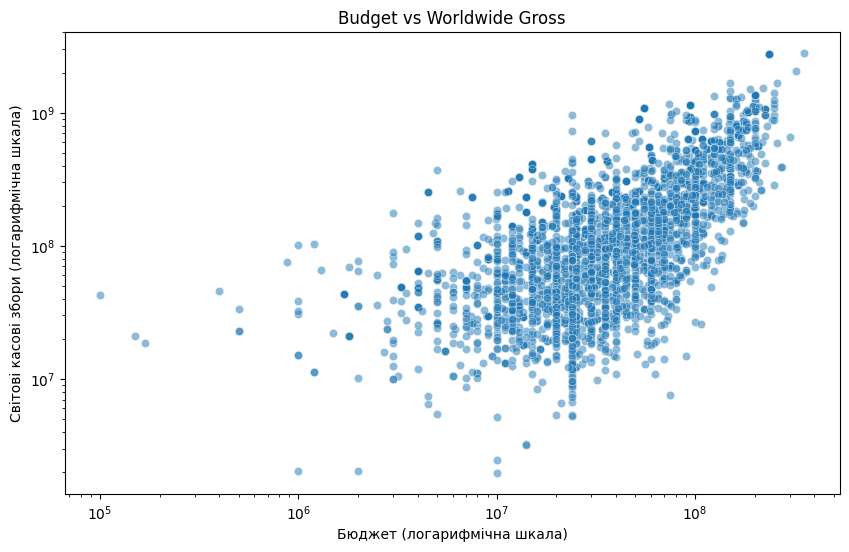

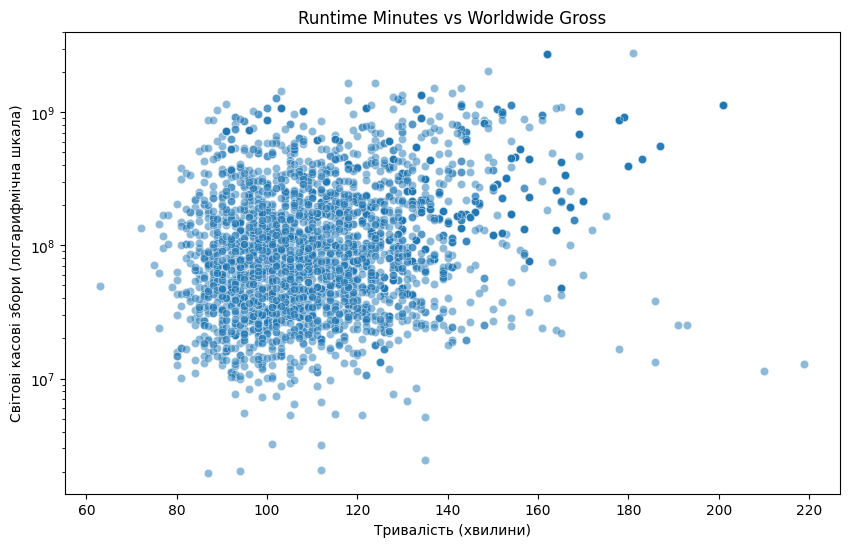

In [14]:
# 1.2. Кореляційний аналіз

# 1. Підготовка даних: вибір числових стовпців
data = df[['budget', 'runtime_minutes', 'worldwide_gross']].copy()

# 2. Обробка пропущених значень: видаляємо рядки з NaN у worldwide_gross
data = data.dropna(subset=['worldwide_gross'])

# 3. Побудова теплової карти кореляцій
plt.figure(figsize=(8, 6))
correlation_matrix = data.corr()  # Обчислення матриці кореляцій
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Теплова карта кореляцій')
plt.show()

# 4. Діаграми розсіювання з логарифмічним масштабуванням
# Budget vs Worldwide Gross
plt.figure(figsize=(10, 6))
sns.scatterplot(x='budget', y='worldwide_gross', data=data, alpha=0.5)
plt.xscale('log')  # Логарифмічна шкала для осі X
plt.yscale('log')  # Логарифмічна шкала для осі Y
plt.xlabel('Бюджет (логарифмічна шкала)')
plt.ylabel('Світові касові збори (логарифмічна шкала)')
plt.title('Budget vs Worldwide Gross')
plt.show()

# Runtime Minutes vs Worldwide Gross
plt.figure(figsize=(10, 6))
sns.scatterplot(x='runtime_minutes', y='worldwide_gross', data=data, alpha=0.5)
plt.yscale('log')  # Логарифмічна шкала для осі Y
plt.xlabel('Тривалість (хвилини)')
plt.ylabel('Світові касові збори (логарифмічна шкала)')
plt.title('Runtime Minutes vs Worldwide Gross')
plt.show()